In [2]:
import pandas as pd

df = pd.read_csv("taxi_sample.csv")
df

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1399190091620000213,B,NaN,10.0,20000213,1399190091,A,False,"[[-8.607096,41.150286],[-8.607123,41.150214],[..."
1,1398928351620000092,C,NaN,NaN,20000092,1398928351,A,False,"[[-8.638533,41.159133],[-8.63856,41.15907],[-8..."
2,1383056851620000263,B,NaN,9.0,20000263,1383056851,A,False,"[[-8.60652,41.144562],[-8.606934,41.144724],[-..."
3,1399758505620000503,B,NaN,13.0,20000503,1399758505,A,False,"[[-8.628246,41.157333],[-8.627733,41.157657],[..."
4,1390920415620000174,B,NaN,10.0,20000174,1390920415,A,False,"[[-8.607123,41.150331],[-8.607114,41.150295],[..."
...,...,...,...,...,...,...,...,...,...
85529,1400616422620000665,C,NaN,NaN,20000665,1400616422,A,False,"[[-8.612748,41.140413],[-8.612766,41.140413],[..."
85530,1392213120620000521,C,NaN,NaN,20000521,1392213120,A,False,"[[-8.632323,41.164479],[-8.632395,41.164326],[..."
85531,1385463326620000499,B,NaN,50.0,20000499,1385463326,A,False,"[[-8.628759,41.169789],[-8.628651,41.169798],[..."
85532,1380912162620000675,B,NaN,60.0,20000675,1380912162,A,False,"[[-8.609652,41.151231],[-8.609616,41.151267],[..."


Le but est de trouver les apoints de prise en charge des taxis. Pour cela on va prendre le points de départs de chaque trajet qui est le point de prise en charge. Avant de faire celà, éliminons les trajets non valide, c'est-à-dire les trajets qui n'ont aucune données GPS.

In [3]:
df_corrected = df.query("`POLYLINE` != '[]'")
df_corrected

,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1399190091620000213,B,NaN,10.0,20000213,1399190091,A,False,"[[-8.607096,41.150286],[-8.607123,41.150214],[..."
1,1398928351620000092,C,NaN,NaN,20000092,1398928351,A,False,"[[-8.638533,41.159133],[-8.63856,41.15907],[-8..."
2,1383056851620000263,B,NaN,9.0,20000263,1383056851,A,False,"[[-8.60652,41.144562],[-8.606934,41.144724],[-..."
3,1399758505620000503,B,NaN,13.0,20000503,1399758505,A,False,"[[-8.628246,41.157333],[-8.627733,41.157657],[..."
4,1390920415620000174,B,NaN,10.0,20000174,1390920415,A,False,"[[-8.607123,41.150331],[-8.607114,41.150295],[..."
...,...,...,...,...,...,...,...,...,...
85529,1400616422620000665,C,NaN,NaN,20000665,1400616422,A,False,"[[-8.612748,41.140413],[-8.612766,41.140413],[..."
85530,1392213120620000521,C,NaN,NaN,20000521,1392213120,A,False,"[[-8.632323,41.164479],[-8.632395,41.164326],[..."
85531,1385463326620000499,B,NaN,50.0,20000499,1385463326,A,False,"[[-8.628759,41.169789],[-8.628651,41.169798],[..."
85532,1380912162620000675,B,NaN,60.0,20000675,1380912162,A,False,"[[-8.609652,41.151231],[-8.609616,41.151267],[..."


Maintenant que le dataset à été néttoyé, on va convertir les coordonnées en métre.

In [4]:
import numpy as np

x = df_corrected["POLYLINE"].str.findall(r"\d+[.,]\d+").apply(lambda x: float(x[0]))
y = df_corrected["POLYLINE"].str.findall(r"\d+[.,]\d+").apply(lambda x: float(x[1]))

# Point de référence
lon0 = x.mean()
lat0 = y.mean()

R = 6_371_000  # rayon terrestre en mètres

x_m = R * np.cos(np.radians(lat0)) * np.radians(x - lon0)
y_m = R * np.radians(y - lat0)

df_coord = pd.DataFrame({"x": x_m, "y": y_m})
df_coord

,x,y
0,-853.434184,-742.023826
1,1778.462571,241.717690
2,-901.656742,-1378.503587
3,917.237838,41.566822
4,-851.173752,-737.020055
...,...,...
85529,-380.250342,-1839.851337
85530,1258.563126,836.165767
85531,960.186053,1426.610828
85532,-639.446587,-636.944621


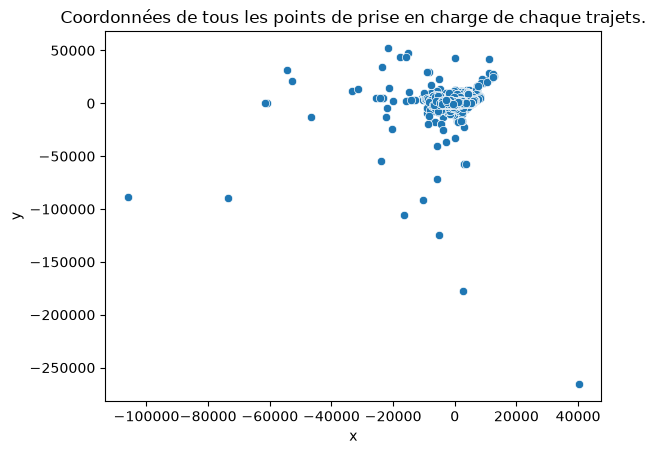

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(df_coord, x="x", y="y")
plt.title("Coordonnées de tous les points de prise en charge de chaque trajets.")
plt.show()

On voit un cluster principale avec quelque point qui s'éloigne. Le but de notre projet n'est pas de faire un clustering parfait mais c'est de trouver les hotspots locaux. Par conséquent on n'utiliseras pas le score de silhouette et on utiliseras 100 métres pour l'epsilon pour obtenir des hotspots réaliste au niveau de la distances réelle et pour le min8samples on va considé&rer qu'un points est un hotspots uniquement si il y a au moins 30 voisins.

In [30]:
from sklearn.cluster import DBSCAN

cluster = DBSCAN(eps=100, min_samples=30).fit_predict(df_coord)

In [ ]:
df_coord["cluster"] = cluster

cluster
 0     52344
-1      5976
 1      4872
 7      3022
 19     2792
       ...  
 67       26
 83       26
 82       24
 73       19
 76        6
Name: count, Length: 85, dtype: int64

In [32]:
df_coord["cluster"].value_counts().sort_values()

cluster
 76        6
 73       19
 82       24
 83       26
 67       26
       ...  
 19     2792
 7      3022
 1      4872
-1      5976
 0     52344
Name: count, Length: 85, dtype: int64

On voit que les 3 plus grand hotspots sont ceux à l'index 0 puis 1 puis 7. 